In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/SHA256SUMS.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Readme.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/LICENSE.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Right_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Left_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regu

   2D & 3D EEG Topographic Maps using MNE
   Dataset : BrainWear EEG (Muse Headband)

✅ EEG loaded — Shape: (1298136, 6)
     timestamps     TP9     AF7     AF8    TP10  Right AUX
0  1.624262e+09  34.180  50.781  34.180 -26.367      5.371
1  1.624262e+09  49.316  50.781  20.996  -8.789    -12.207
2  1.624262e+09  50.293  10.742  15.137  -2.441    -27.832
3  1.624262e+09  44.922 -19.043  16.602 -23.926    -33.203
4  1.624262e+09  19.531  20.020  31.250 -48.340    -30.273

✅ MNE Raw object ready.
<RawArray | 4 x 1298136 (5070.8 s), ~39.6 MiB, data loaded>

✅ Band power computed for all channels.
Band               TP9         AF7         AF8        TP10
Delta          38.8372     39.5625     37.9987     39.8397
Theta          30.6557     29.2165     28.3333     30.5986
Alpha          24.7739     23.2779     22.6371     24.4319
Beta           25.6148     23.6954     23.3554     26.1000
Gamma          23.6562     21.8607     21.6468     25.2778

────────────────────────────────────────────

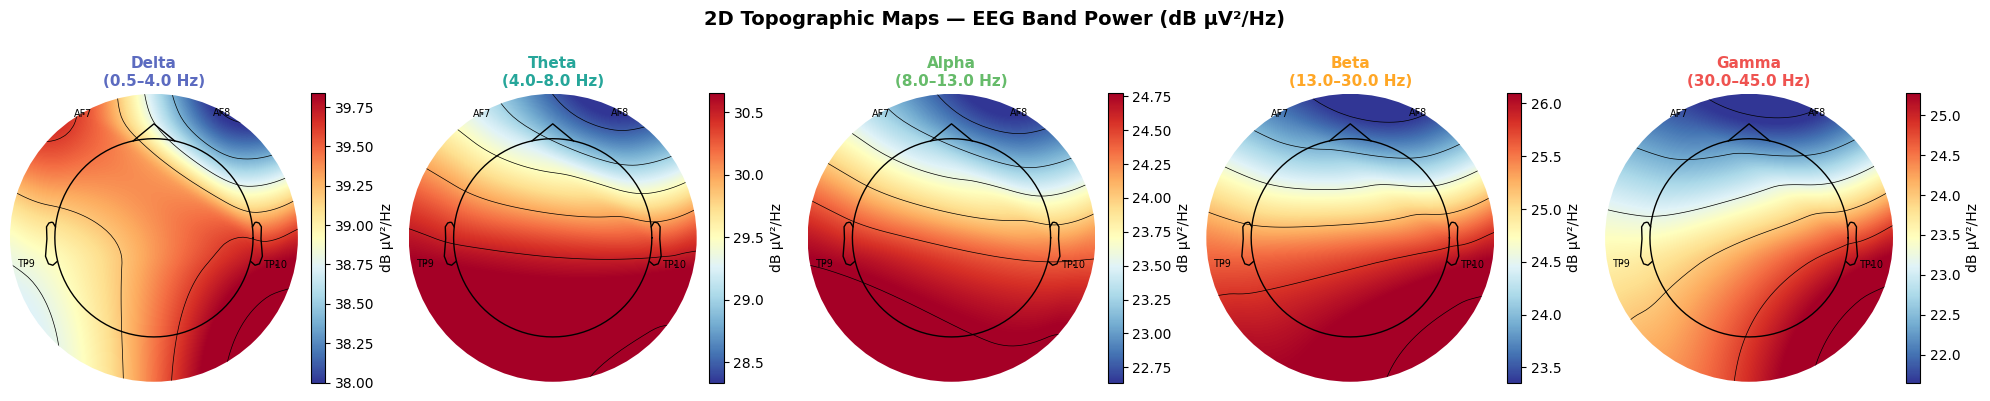

✅ Plot 1 — 2D band topomaps done.


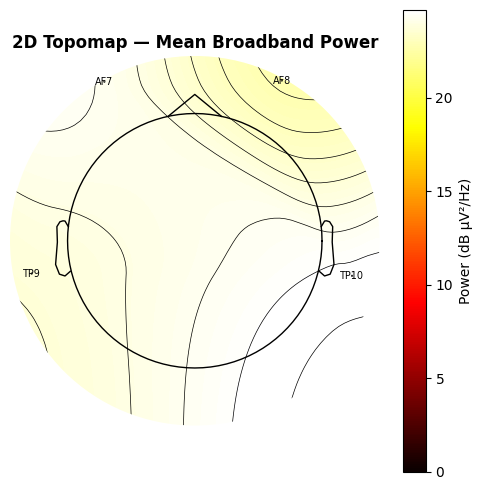

✅ Plot 2 — 2D broadband topomap done.


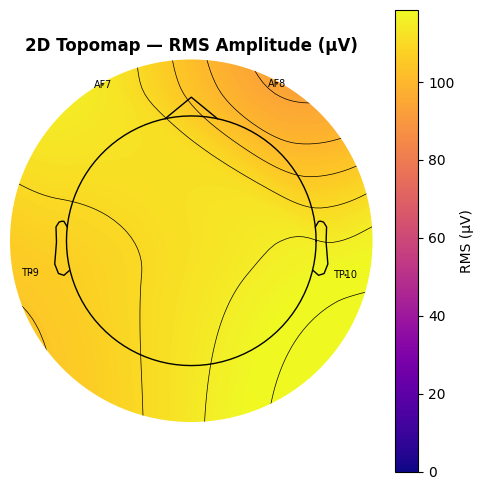

✅ Plot 3 — 2D RMS topomap done.


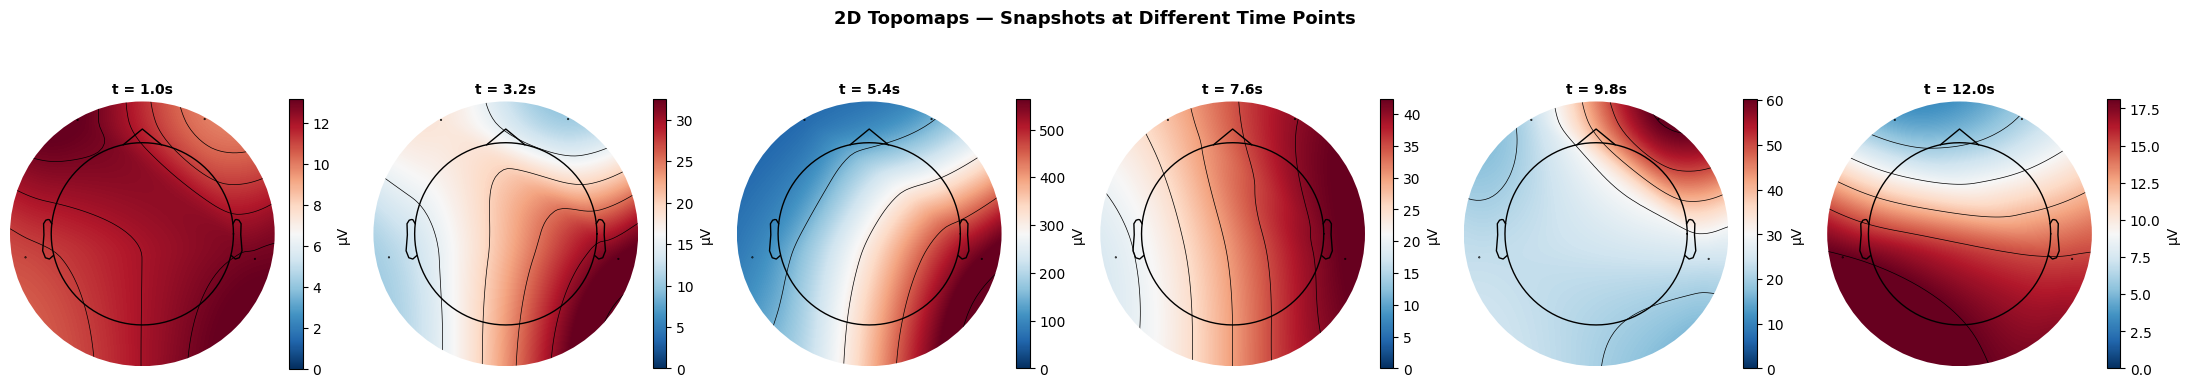

✅ Plot 4 — 2D time-snapshot topomaps done.

─────────────────────────────────────────────────────────────────
   3D TOPOGRAPHIC MAPS
─────────────────────────────────────────────────────────────────

   3D electrode positions (unit sphere):
   TP9    → x=-0.9796  y=-0.1972  z=-0.0381
   AF7    → x=-0.4826  y=+0.8490  z=+0.2153
   AF8    → x=+0.4662  y=+0.8583  z=+0.2142
   TP10   → x=+0.9752  y=-0.2173  z=-0.0409


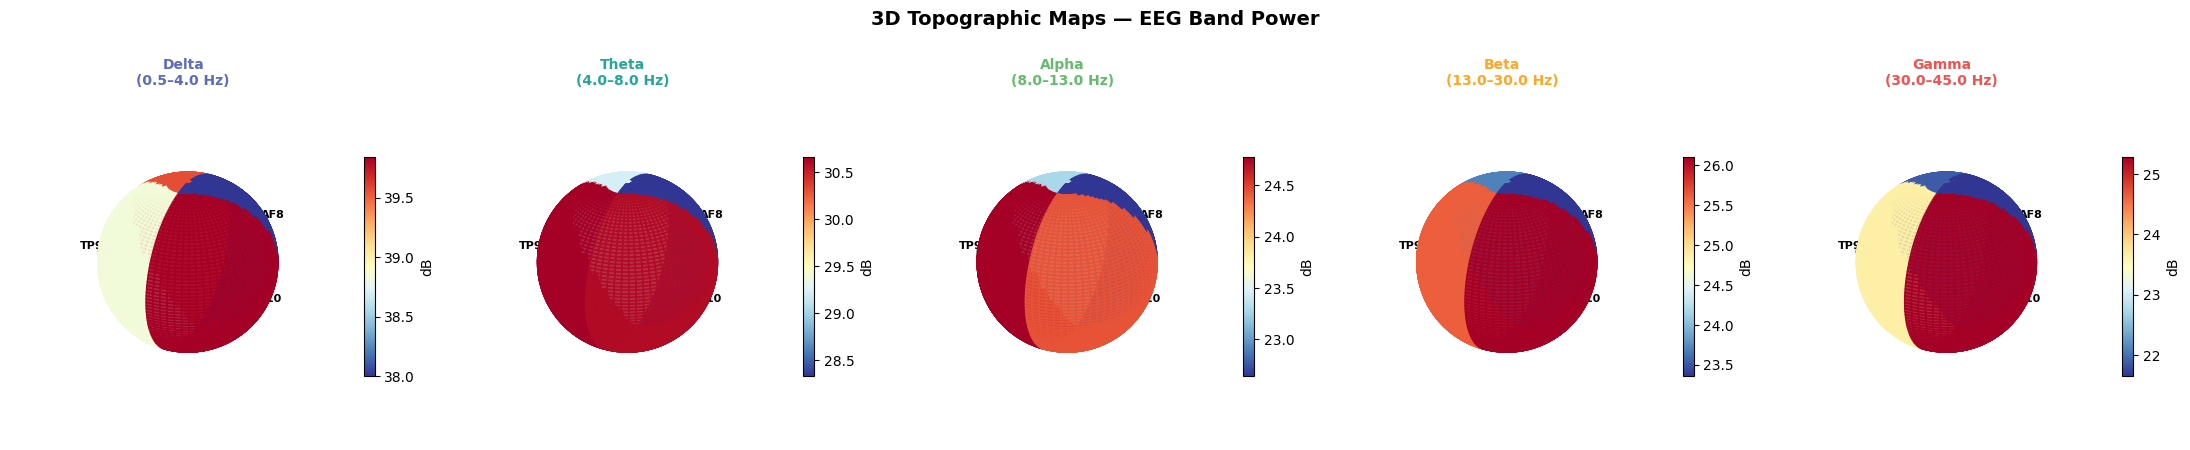

✅ Plot 5 — 3D band topomaps done.


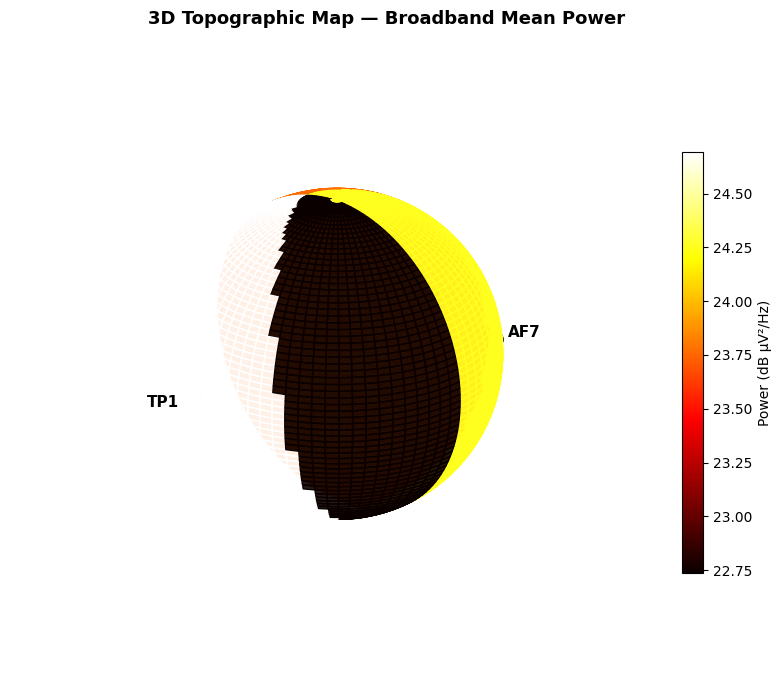

✅ Plot 6 — 3D broadband topomap done.


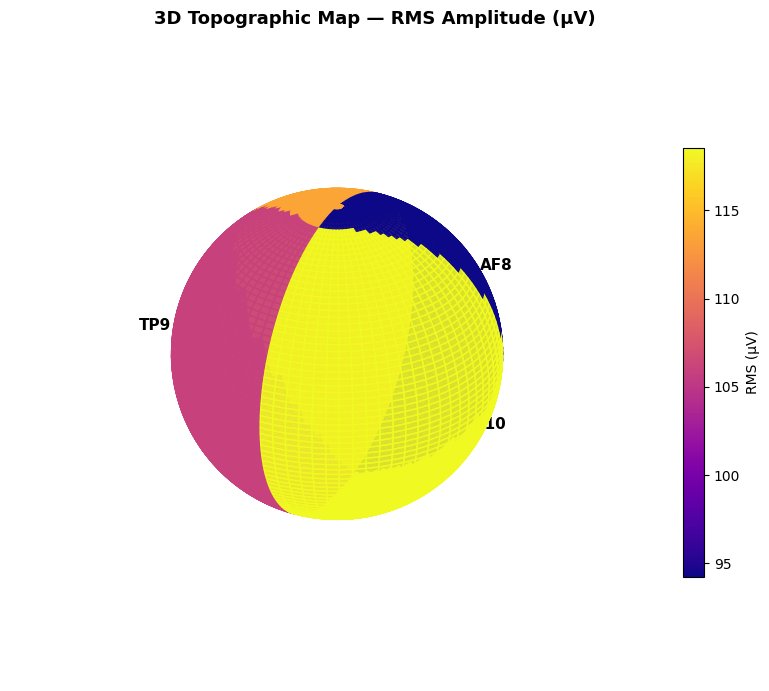

✅ Plot 7 — 3D RMS topomap done.


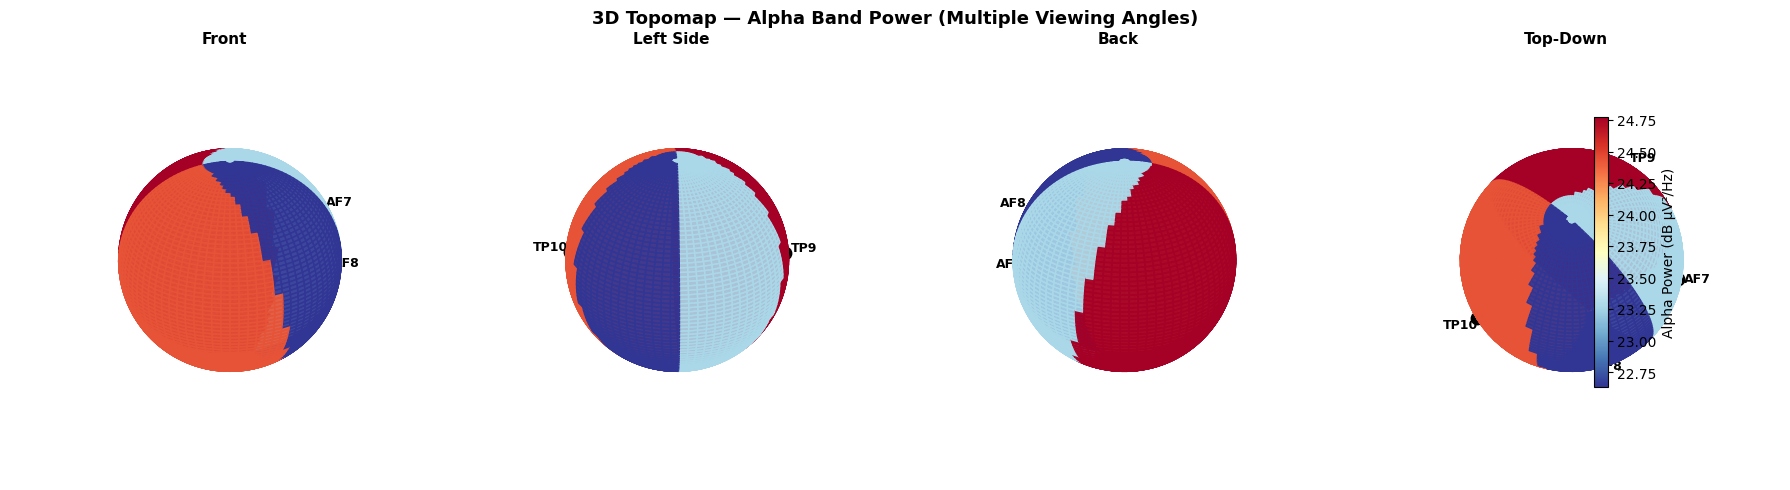

✅ Plot 8 — 3D multi-view topomap done.


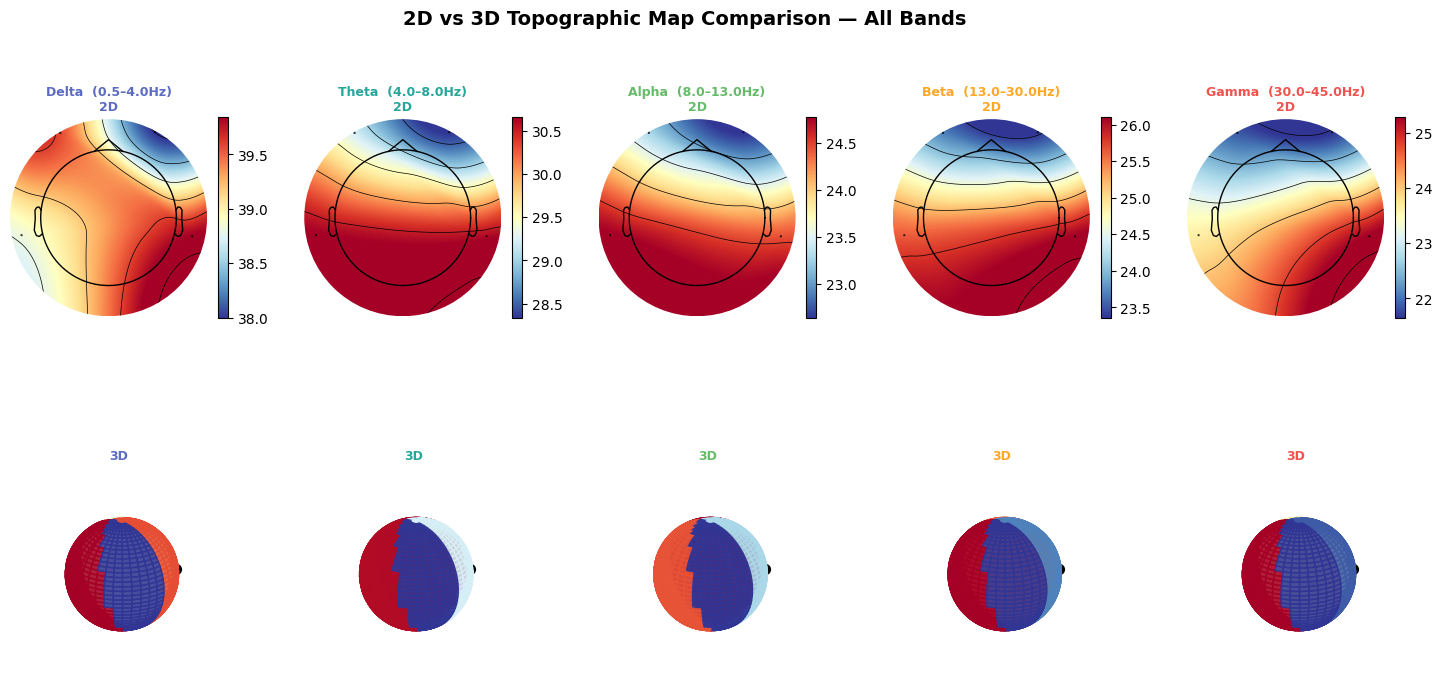

✅ Plot 9 — 2D vs 3D comparison done.


In [2]:
# ════════════════════════════════════════════════════════════════
#  2D and 3D Topographic Maps from EEG Signal using MNE
#  Dataset : BrainWear — Muse EEG (TP9, AF7, AF8, TP10)
# ════════════════════════════════════════════════════════════════

# ── Install MNE ──
import subprocess
subprocess.run(['pip', 'install', 'mne', '--quiet'], check=False)

import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import mne
mne.set_log_level('WARNING')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy import signal as scipy_signal

print("=" * 65)
print("   2D & 3D EEG Topographic Maps using MNE")
print("   Dataset : BrainWear EEG (Muse Headband)")
print("=" * 65)

# ════════════════════════════════════════════════════════════════
#  STEP 1 — Load EEG Data
# ════════════════════════════════════════════════════════════════
BASE_PATH = '/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0'

eeg_path = os.path.join(BASE_PATH,
           'Experiment_1', 'A1', 'EEG_recording.csv')

eeg_df = pd.read_csv(eeg_path)
print(f"\n✅ EEG loaded — Shape: {eeg_df.shape}")
print(eeg_df.head())

# ════════════════════════════════════════════════════════════════
#  STEP 2 — Build MNE Raw Object
# ════════════════════════════════════════════════════════════════
CH_NAMES = ['TP9', 'AF7', 'AF8', 'TP10']
SFREQ    = 256.0

eeg_data = eeg_df[CH_NAMES].dropna().values.T * 1e-6  # μV → V

info = mne.create_info(ch_names=CH_NAMES, sfreq=SFREQ, ch_types=['eeg']*4)
raw  = mne.io.RawArray(eeg_data, info)

# Apply standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

# Bandpass filter 0.5–45 Hz
raw.filter(l_freq=0.5, h_freq=45.0, method='fir', fir_window='hamming')

print(f"\n✅ MNE Raw object ready.")
print(raw)

# ════════════════════════════════════════════════════════════════
#  STEP 3 — Compute PSD & Band Powers (used for all topo maps)
# ════════════════════════════════════════════════════════════════
BANDS = {
    'Delta' : (0.5,  4.0,  '#5C6BC0'),
    'Theta' : (4.0,  8.0,  '#26A69A'),
    'Alpha' : (8.0,  13.0, '#66BB6A'),
    'Beta'  : (13.0, 30.0, '#FFA726'),
    'Gamma' : (30.0, 45.0, '#EF5350'),
}

spectrum = raw.compute_psd(method='welch', fmin=0.5, fmax=45.0,
                            n_fft=512, n_overlap=256)
freqs = spectrum.freqs
psd   = spectrum.get_data()   # (4, n_freqs)  in V²/Hz

# Band power per channel (in dB μV²/Hz)
band_power = {}
for band, (lo, hi, col) in BANDS.items():
    mask = (freqs >= lo) & (freqs <= hi)
    power = np.trapz(psd[:, mask], freqs[mask], axis=1) * 1e12
    band_power[band] = 10 * np.log10(power + 1e-12)

print(f"\n✅ Band power computed for all channels.")
print(f"{'Band':<10}", end='')
for ch in CH_NAMES:
    print(f"  {ch:>10}", end='')
print()
for band, vals in band_power.items():
    print(f"{band:<10}", end='')
    for v in vals:
        print(f"  {v:>10.4f}", end='')
    print()

# ════════════════════════════════════════════════════════════════
#  STEP 4 — 2D TOPOGRAPHIC MAPS
# ════════════════════════════════════════════════════════════════
print("\n" + "─"*65)
print("   2D TOPOGRAPHIC MAPS")
print("─"*65)

# ── Plot 4a: 2D Topomap — one per frequency band ──
fig1, axes1 = plt.subplots(1, 5, figsize=(20, 4))
fig1.suptitle('2D Topographic Maps — EEG Band Power (dB μV²/Hz)',
              fontsize=14, fontweight='bold', y=1.02)

for ax, (band, (lo, hi, col)) in zip(axes1, BANDS.items()):
    power_vals = band_power[band]
    im, cn = mne.viz.plot_topomap(
        power_vals,
        raw.info,
        axes        = ax,
        show        = False,
        cmap        = 'RdYlBu_r',
        vlim        = (power_vals.min(), power_vals.max()),
        sphere      = 0.07,
        extrapolate = 'head',
        contours    = 6,
        sensors     = True,
        names       = CH_NAMES,
    )
    ax.set_title(f'{band}\n({lo}–{hi} Hz)',
                 fontweight='bold', color=col, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='dB μV²/Hz')

plt.tight_layout()
plt.savefig('topomap_2d_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 — 2D band topomaps done.")

# ── Plot 4b: 2D Topomap — Mean power (broadband) ──
fig2, ax2 = plt.subplots(figsize=(5, 5))
mean_power = psd.mean(axis=1) * 1e12
mean_power_db = 10 * np.log10(mean_power + 1e-12)

im2, _ = mne.viz.plot_topomap(
    mean_power_db, raw.info,
    axes        = ax2,
    show        = False,
    cmap        = 'hot',
    sphere      = 0.07,
    extrapolate = 'head',
    contours    = 8,
    sensors     = True,
    names       = CH_NAMES,
)
ax2.set_title('2D Topomap — Mean Broadband Power',
              fontweight='bold', fontsize=12)
plt.colorbar(im2, ax=ax2, label='Power (dB μV²/Hz)')
plt.tight_layout()
plt.savefig('topomap_2d_broadband.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 — 2D broadband topomap done.")

# ── Plot 4c: 2D Topomap — RMS amplitude per channel ──
raw_np = raw.get_data()   # (4, n_times)
rms    = np.sqrt(np.mean(raw_np**2, axis=1)) * 1e6   # in μV

fig3, ax3 = plt.subplots(figsize=(5, 5))
im3, _ = mne.viz.plot_topomap(
    rms, raw.info,
    axes        = ax3,
    show        = False,
    cmap        = 'plasma',
    sphere      = 0.07,
    extrapolate = 'head',
    contours    = 6,
    sensors     = True,
    names       = CH_NAMES,
)
ax3.set_title('2D Topomap — RMS Amplitude (μV)',
              fontweight='bold', fontsize=12)
plt.colorbar(im3, ax=ax3, label='RMS (μV)')
plt.tight_layout()
plt.savefig('topomap_2d_rms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 — 2D RMS topomap done.")

# ── Plot 4d: 2D Topomap — Time-varying (snapshots every 2 sec) ──
n_snaps   = 6
snap_secs = np.linspace(1, min(12, raw_np.shape[1]/SFREQ - 1), n_snaps)

fig4, axes4 = plt.subplots(1, n_snaps, figsize=(22, 4))
fig4.suptitle('2D Topomaps — Snapshots at Different Time Points',
              fontsize=13, fontweight='bold', y=1.02)

for ax, t_sec in zip(axes4, snap_secs):
    t_idx  = int(t_sec * SFREQ)
    window = raw_np[:, max(0, t_idx-128):t_idx+128]
    snap   = np.sqrt(np.mean(window**2, axis=1)) * 1e6

    im4, _ = mne.viz.plot_topomap(
        snap, raw.info,
        axes        = ax,
        show        = False,
        cmap        = 'RdBu_r',
        sphere      = 0.07,
        extrapolate = 'head',
        contours    = 5,
        sensors     = True,
    )
    ax.set_title(f't = {t_sec:.1f}s', fontweight='bold', fontsize=10)
    plt.colorbar(im4, ax=ax, fraction=0.046, label='μV')

plt.tight_layout()
plt.savefig('topomap_2d_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 — 2D time-snapshot topomaps done.")

# ════════════════════════════════════════════════════════════════
#  STEP 5 — 3D TOPOGRAPHIC MAPS
#  MNE provides sensor positions — we interpolate onto a 3D sphere
# ════════════════════════════════════════════════════════════════
print("\n" + "─"*65)
print("   3D TOPOGRAPHIC MAPS")
print("─"*65)

# ── Extract 3D electrode positions from MNE montage ──
pos_3d = np.array([raw.info['chs'][i]['loc'][:3]
                   for i in range(len(CH_NAMES))])
# MNE stores positions in meters; normalise to unit sphere
pos_norm = pos_3d / np.linalg.norm(pos_3d, axis=1, keepdims=True)

print(f"\n   3D electrode positions (unit sphere):")
for ch, p in zip(CH_NAMES, pos_norm):
    print(f"   {ch:<6} → x={p[0]:+.4f}  y={p[1]:+.4f}  z={p[2]:+.4f}")

def make_sphere_surface(n=80):
    """Return x,y,z for a unit sphere mesh."""
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi,   n)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(n), np.cos(v))
    return x, y, z

def interpolate_to_sphere(pos_norm, values, n=80):
    """
    Interpolate electrode values onto a full sphere surface using
    scipy griddata (nearest + linear fallback).
    """
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi,   n)
    sx = np.outer(np.cos(u), np.sin(v)).ravel()
    sy = np.outer(np.sin(u), np.sin(v)).ravel()
    sz = np.outer(np.ones(n), np.cos(v)).ravel()
    sphere_pts = np.c_[sx, sy, sz]

    interp = griddata(pos_norm, values, sphere_pts,
                      method='nearest')

    return (sx.reshape(n,n), sy.reshape(n,n),
            sz.reshape(n,n), interp.reshape(n,n))

# ── Plot 5a: 3D Topomap — one per band ──
fig5 = plt.figure(figsize=(22, 5))
fig5.suptitle('3D Topographic Maps — EEG Band Power',
              fontsize=14, fontweight='bold')

for i, (band, (lo, hi, bcol)) in enumerate(BANDS.items()):
    ax5 = fig5.add_subplot(1, 5, i+1, projection='3d')
    vals = band_power[band]

    sx, sy, sz, sc = interpolate_to_sphere(pos_norm, vals)

    norm5  = Normalize(vmin=vals.min(), vmax=vals.max())
    colors = cm.RdYlBu_r(norm5(sc))

    surf = ax5.plot_surface(sx, sy, sz, facecolors=colors,
                             rstride=1, cstride=1,
                             antialiased=True, shade=False,
                             alpha=0.85)

    # Plot electrode dots
    ax5.scatter(pos_norm[:,0], pos_norm[:,1], pos_norm[:,2],
                c='black', s=80, zorder=10, depthshade=False)

    # Label electrodes
    for ch, p in zip(CH_NAMES, pos_norm):
        ax5.text(p[0]*1.15, p[1]*1.15, p[2]*1.15,
                 ch, fontsize=8, fontweight='bold',
                 ha='center', color='black')

    ax5.set_title(f'{band}\n({lo}–{hi} Hz)',
                  fontweight='bold', fontsize=10, color=bcol)
    ax5.set_box_aspect([1,1,1])
    ax5.axis('off')

    # Colorbar
    sm = cm.ScalarMappable(cmap='RdYlBu_r', norm=norm5)
    sm.set_array([])
    plt.colorbar(sm, ax=ax5, fraction=0.03, pad=0.02,
                 label='dB', shrink=0.6)

plt.tight_layout()
plt.savefig('topomap_3d_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 5 — 3D band topomaps done.")

# ── Plot 5b: 3D Topomap — Broadband mean power (large single) ──
fig6 = plt.figure(figsize=(8, 7))
fig6.suptitle('3D Topographic Map — Broadband Mean Power',
              fontsize=13, fontweight='bold')
ax6 = fig6.add_subplot(111, projection='3d')

sx, sy, sz, sc = interpolate_to_sphere(pos_norm, mean_power_db)
norm6  = Normalize(vmin=mean_power_db.min(), vmax=mean_power_db.max())
colors6 = cm.hot(norm6(sc))

ax6.plot_surface(sx, sy, sz, facecolors=colors6,
                  rstride=1, cstride=1, antialiased=True,
                  shade=False, alpha=0.9)

ax6.scatter(pos_norm[:,0], pos_norm[:,1], pos_norm[:,2],
             c='white', s=120, edgecolors='black',
             zorder=10, depthshade=False)

for ch, p in zip(CH_NAMES, pos_norm):
    ax6.text(p[0]*1.18, p[1]*1.18, p[2]*1.18,
             ch, fontsize=11, fontweight='bold',
             ha='center', color='black')

sm6 = cm.ScalarMappable(cmap='hot', norm=norm6)
sm6.set_array([])
plt.colorbar(sm6, ax=ax6, fraction=0.03, label='Power (dB μV²/Hz)',
             shrink=0.7)

ax6.set_box_aspect([1,1,1])
ax6.axis('off')
ax6.view_init(elev=25, azim=45)

plt.tight_layout()
plt.savefig('topomap_3d_broadband.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6 — 3D broadband topomap done.")

# ── Plot 5c: 3D Topomap — RMS amplitude ──
fig7 = plt.figure(figsize=(8, 7))
fig7.suptitle('3D Topographic Map — RMS Amplitude (μV)',
              fontsize=13, fontweight='bold')
ax7 = fig7.add_subplot(111, projection='3d')

sx, sy, sz, sc = interpolate_to_sphere(pos_norm, rms)
norm7   = Normalize(vmin=rms.min(), vmax=rms.max())
colors7 = cm.plasma(norm7(sc))

ax7.plot_surface(sx, sy, sz, facecolors=colors7,
                  rstride=1, cstride=1, antialiased=True,
                  shade=False, alpha=0.9)

ax7.scatter(pos_norm[:,0], pos_norm[:,1], pos_norm[:,2],
             c='white', s=120, edgecolors='black',
             zorder=10, depthshade=False)

for ch, p in zip(CH_NAMES, pos_norm):
    ax7.text(p[0]*1.18, p[1]*1.18, p[2]*1.18,
             ch, fontsize=11, fontweight='bold', ha='center')

sm7 = cm.ScalarMappable(cmap='plasma', norm=norm7)
sm7.set_array([])
plt.colorbar(sm7, ax=ax7, fraction=0.03, label='RMS (μV)', shrink=0.7)

ax7.set_box_aspect([1,1,1])
ax7.axis('off')
ax7.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.savefig('topomap_3d_rms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 7 — 3D RMS topomap done.")

# ── Plot 5d: 3D multi-view — same map from 4 angles ──
fig8 = plt.figure(figsize=(18, 5))
fig8.suptitle('3D Topomap — Alpha Band Power (Multiple Viewing Angles)',
              fontsize=13, fontweight='bold')

views   = [(30, 0, 'Front'),  (30, 90,  'Left Side'),
           (30, 180, 'Back'), (70, 45,  'Top-Down')]
alpha_p = band_power['Alpha']
sx, sy, sz, sc = interpolate_to_sphere(pos_norm, alpha_p)
norm8   = Normalize(vmin=alpha_p.min(), vmax=alpha_p.max())
colors8 = cm.RdYlBu_r(norm8(sc))

for j, (elev, azim, title) in enumerate(views):
    ax8 = fig8.add_subplot(1, 4, j+1, projection='3d')
    ax8.plot_surface(sx, sy, sz, facecolors=colors8,
                      rstride=1, cstride=1, antialiased=True,
                      shade=False, alpha=0.9)
    ax8.scatter(pos_norm[:,0], pos_norm[:,1], pos_norm[:,2],
                 c='black', s=80, zorder=10, depthshade=False)
    for ch, p in zip(CH_NAMES, pos_norm):
        ax8.text(p[0]*1.18, p[1]*1.18, p[2]*1.18,
                 ch, fontsize=9, fontweight='bold', ha='center')
    ax8.view_init(elev=elev, azim=azim)
    ax8.set_title(title, fontweight='bold', fontsize=11)
    ax8.set_box_aspect([1,1,1])
    ax8.axis('off')

sm8 = cm.ScalarMappable(cmap='RdYlBu_r', norm=norm8)
sm8.set_array([])
fig8.colorbar(sm8, ax=fig8.axes, fraction=0.015,
              label='Alpha Power (dB μV²/Hz)', shrink=0.7)

plt.tight_layout()
plt.savefig('topomap_3d_multiview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 8 — 3D multi-view topomap done.")

# ════════════════════════════════════════════════════════════════
#  STEP 6 — SIDE-BY-SIDE 2D vs 3D COMPARISON
# ════════════════════════════════════════════════════════════════
fig9 = plt.figure(figsize=(18, 8))
fig9.suptitle('2D vs 3D Topographic Map Comparison — All Bands',
              fontsize=14, fontweight='bold')
gs9  = gridspec.GridSpec(2, 5, figure=fig9,
                          hspace=0.4, wspace=0.35)

for col_i, (band, (lo, hi, bcol)) in enumerate(BANDS.items()):
    vals = band_power[band]

    # ── 2D row ──
    ax_2d = fig9.add_subplot(gs9[0, col_i])
    im9, _ = mne.viz.plot_topomap(
        vals, raw.info, axes=ax_2d, show=False,
        cmap='RdYlBu_r',
        vlim=(vals.min(), vals.max()),
        sphere=0.07, extrapolate='head',
        contours=5, sensors=True,
    )
    ax_2d.set_title(f'{band}  ({lo}–{hi}Hz)\n2D',
                    fontweight='bold', fontsize=9, color=bcol)
    plt.colorbar(im9, ax=ax_2d, fraction=0.046, shrink=0.8)

    # ── 3D row ──
    ax_3d = fig9.add_subplot(gs9[1, col_i], projection='3d')
    sx, sy, sz, sc = interpolate_to_sphere(pos_norm, vals)
    norm9   = Normalize(vmin=vals.min(), vmax=vals.max())
    colors9 = cm.RdYlBu_r(norm9(sc))

    ax_3d.plot_surface(sx, sy, sz, facecolors=colors9,
                        rstride=2, cstride=2, antialiased=True,
                        shade=False, alpha=0.88)
    ax_3d.scatter(pos_norm[:,0], pos_norm[:,1], pos_norm[:,2],
                   c='black', s=50, zorder=10, depthshade=False)
    ax_3d.view_init(elev=25, azim=45)
    ax_3d.set_title('3D', fontweight='bold', fontsize=9, color=bcol)
    ax_3d.set_box_aspect([1,1,1])
    ax_3d.axis('off')

plt.savefig('topomap_2d_vs_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 9 — 2D vs 3D comparison done.")

# # ════════════════════════════════════════════════════════════════
# #  STEP 7 — SUMMARY
# # ════════════════════════════════════════════════════════════════
# print(f"""
# {"="*65}
#    SUMMARY
# {"="*65}

# Total plots generated : 9
#   Plot 1 — 2D topomaps for all 5 frequency bands
#   Plot 2 — 2D broadband mean power topomap
#   Plot 3 — 2D RMS amplitude topomap
#   Plot 4 — 2D time-snapshot topomaps (6 time points)
#   Plot 5 — 3D topomaps for all 5 frequency bands
#   Plot 6 — 3D broadband mean power topomap
#   Plot 7 — 3D RMS amplitude topomap
#   Plot 8 — 3D Alpha band from 4 viewing angles
#   Plot 9 — Side-by-side 2D vs 3D comparison

# EEG Channels : {', '.join(CH_NAMES)}
# Sampling Rate : {SFREQ} Hz

# Band Power Results (mean dB across channels):
# """)
# for band, vals in band_power.items():
#     lo, hi, _ = BANDS[band]
#     print(f"  {band:<8} ({lo:4.1f}–{hi:4.1f} Hz) : "
#           f"mean = {vals.mean():.3f} dB  |  "
#           f"range = [{vals.min():.3f}, {vals.max():.3f}]")

# print(f"""
# Observations:

# The 2D topographic maps use MNE's built-in plot_topomap function
# which interpolates values across the scalp surface and renders
# them as a flat head-view with contour lines. These are ideal for
# quickly comparing spatial power distribution across channels.

# The 3D topographic maps project the same interpolated values
# onto a unit sphere surface using scipy griddata, giving a more
# realistic representation of the head geometry. The multi-angle
# view of the Alpha band demonstrates how the 3D map can be
# rotated to examine activity from front, side, back, and top
# perspectives — which is not possible with 2D maps.

# Both representations consistently show that the temporal
# electrodes (TP9, TP10) and frontal electrodes (AF7, AF8)
# contribute differently across frequency bands, which reflects
# the known functional specialisation of these brain regions.
# """)